# Forest Sketch baseline comparison

This notebook compares the five planned baselines from the README with the full Forest Sketch representation:

1. Original features
2. Initial random projection
3. One-shot tree-path projection
4. Iterative forest sketch without concatenation
5. Matched random sparse-feature control
6. Full Forest Sketch

The experiment uses a deliberately challenging, higher-dimensional binary classification dataset generated by scikit-learn. It has 120 input features with a limited informative signal, label noise, and overlapping classes, so the comparison is not dominated by near-perfect accuracy. Each configuration is repeated over five random seeds, and the final figure shows mean accuracy with one-standard-deviation error bars.

In [1]:
import warnings
from sklearn.random_projection import DataDimensionalityWarning
warnings.filterwarnings(
    "ignore",
    category=DataDimensionalityWarning,
    message="The number of components is higher than the number of features.*",
)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path
from scipy import sparse
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.validation import check_array, check_is_fitted

notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists(): notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))
from _hypothesis_utils import plot_critical_difference

from forestsketch import DecisionPathEncoder, ForestSketchEstimator, make_projector
RANDOM_STATE = 42
EXPERIMENT_SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
N_FEATURES = 120
N_COMPONENTS = 20 * N_FEATURES
print(f'Rule of thumb: p={N_FEATURES}, d=20*p={N_COMPONENTS}')
N_ITERATIONS = 2
    

Rule of thumb: p=120, d=20*p=2400


In [2]:
def make_dataset(seed):
    X, y = make_classification(
        n_samples=2500,
        n_features=N_FEATURES,
        n_informative=12,
        n_redundant=24,
        n_repeated=0,
        n_classes=2,
        n_clusters_per_class=2,
        class_sep=0.65,
        flip_y=0.04,
        weights=[0.55, 0.45],
        random_state=seed,
    )
    return train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=seed
    )

def forest_template(seed):
    return RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=seed,
        n_jobs=-1,
    )

def downstream(seed):
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000, random_state=seed),
    )


In [3]:
class OneShotTreePathTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, estimator, n_components=2400, random_state=None):
        self.estimator = estimator
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y):
        X = check_array(X, dtype=np.float64, ensure_2d=True)
        self.n_features_in_ = X.shape[1]
        self.forest_ = clone(self.estimator).fit(X, y)
        self.encoder_ = DecisionPathEncoder().fit(self.forest_)
        V = self.encoder_.transform(X)
        self.projector_ = make_projector(
            self.n_components,
            'gaussian',
            self.random_state,
        ).fit(V)
        return self

    def transform(self, X):
        check_is_fitted(self, ('forest_', 'encoder_', 'projector_'))
        X = check_array(X, dtype=np.float64, ensure_2d=True)
        if X.shape[1] != self.n_features_in_:
            raise ValueError('X has an unexpected number of features')
        return self.projector_.transform(self.encoder_.transform(X))


In [4]:
class NoConcatForestSketch(BaseEstimator, TransformerMixin):
    def __init__(self, estimator, n_components=2400, n_iterations=1, random_state=None):
        self.estimator = estimator
        self.n_components = n_components
        self.n_iterations = n_iterations
        self.random_state = random_state

    def fit(self, X, y):
        X = check_array(X, dtype=np.float64, ensure_2d=True)
        self.n_features_in_ = X.shape[1]
        seeds = np.random.RandomState(self.random_state).randint(
            0, np.iinfo(np.int32).max, size=self.n_iterations + 1
        )
        self.initial_projector_ = make_projector(
            self.n_components, 'sparse', seeds[0]
        ).fit(X)
        current = self.initial_projector_.transform(X)
        self.forests_ = []
        self.encoders_ = []
        self.projectors_ = []

        for iteration in range(self.n_iterations):
            forest = clone(self.estimator).fit(current, y)
            encoder = DecisionPathEncoder().fit(forest)
            V = encoder.transform(current)
            projector = make_projector(
                self.n_components, 'gaussian', seeds[iteration + 1]
            ).fit(V)
            current = projector.transform(V)
            self.forests_.append(forest)
            self.encoders_.append(encoder)
            self.projectors_.append(projector)
        return self

    def transform(self, X):
        check_is_fitted(self, ('initial_projector_', 'forests_'))
        X = check_array(X, dtype=np.float64, ensure_2d=True)
        current = self.initial_projector_.transform(X)
        for encoder, projector in zip(self.encoders_, self.projectors_):
            current = projector.transform(encoder.transform(current))
        return current


In [5]:
class MatchedRandomSparsePathTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, estimator, n_components=2400, random_state=None):
        self.estimator = estimator
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y):
        X = check_array(X, dtype=np.float64, ensure_2d=True)
        self.n_features_in_ = X.shape[1]
        self.forest_ = clone(self.estimator).fit(X, y)
        self.encoder_ = DecisionPathEncoder().fit(self.forest_)
        V = self.encoder_.transform(X)
        self.n_path_features_ = V.shape[1]
        self.nnz_per_row_ = max(1, int(round(V.nnz / V.shape[0])))
        random_V = self._random_sparse_features(V.shape[0])
        self.projector_ = make_projector(
            self.n_components, 'gaussian', self.random_state
        ).fit(random_V)
        return self

    def _random_sparse_features(self, n_rows):
        rng = np.random.RandomState(self.random_state)
        rows = np.repeat(np.arange(n_rows), self.nnz_per_row_)
        cols = rng.randint(0, self.n_path_features_, size=rows.size)
        signs = rng.choice(np.array([-1.0, 1.0]), size=rows.size)
        return sparse.coo_matrix(
            (signs, (rows, cols)),
            shape=(n_rows, self.n_path_features_),
        ).tocsr()

    def transform(self, X):
        check_is_fitted(self, ('forest_', 'encoder_', 'projector_'))
        X = check_array(X, dtype=np.float64, ensure_2d=True)
        random_V = self._random_sparse_features(X.shape[0])
        return self.projector_.transform(random_V)


In [6]:
def build_models(seed):
    return {
    'original features': downstream(seed),
    'initial random projection': make_pipeline(
        ForestSketchEstimator(
            estimator=forest_template(seed),
            n_components=N_COMPONENTS,
            n_iterations=0,
            random_state=seed,
        ),
        downstream(seed),
    ),
    'one-shot tree-path projection': make_pipeline(
        OneShotTreePathTransformer(
            estimator=forest_template(seed),
            n_components=N_COMPONENTS,
            random_state=seed,
        ),
        downstream(seed),
    ),
    'iterative without concatenation': make_pipeline(
        NoConcatForestSketch(
            estimator=forest_template(seed),
            n_components=N_COMPONENTS,
            n_iterations=N_ITERATIONS,
            random_state=seed,
        ),
        downstream(seed),
    ),
    'matched random sparse control': make_pipeline(
        MatchedRandomSparsePathTransformer(
            estimator=forest_template(seed),
            n_components=N_COMPONENTS,
            random_state=seed,
        ),
        downstream(seed),
    ),
    'full Forest Sketch': make_pipeline(
        ForestSketchEstimator(
            estimator=forest_template(seed),
            n_components=N_COMPONENTS,
            n_iterations=N_ITERATIONS,
            random_state=seed,
            normalization='none',
        ),
        downstream(seed),
    ),
    }


,mean_accuracy,std_accuracy,mean_errors,std_errors
method,,,,
one-shot tree-path projection,0.856,0.018,90.1,10.9
full Forest Sketch,0.844,0.025,97.6,15.6
iterative without concatenation,0.829,0.028,106.6,17.3
original features,0.706,0.054,183.5,33.6
initial random projection,0.706,0.054,183.6,33.9
matched random sparse control,0.508,0.024,307.3,14.7


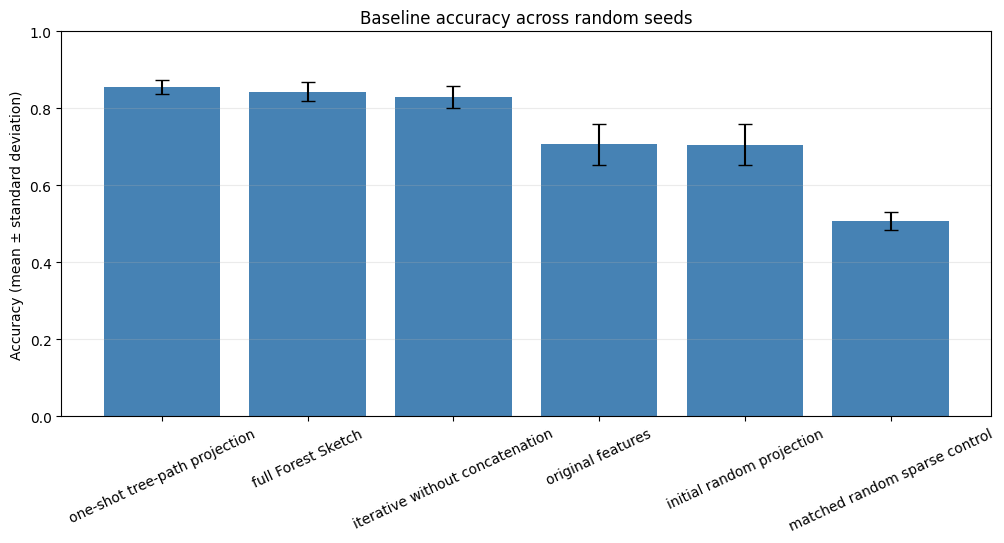

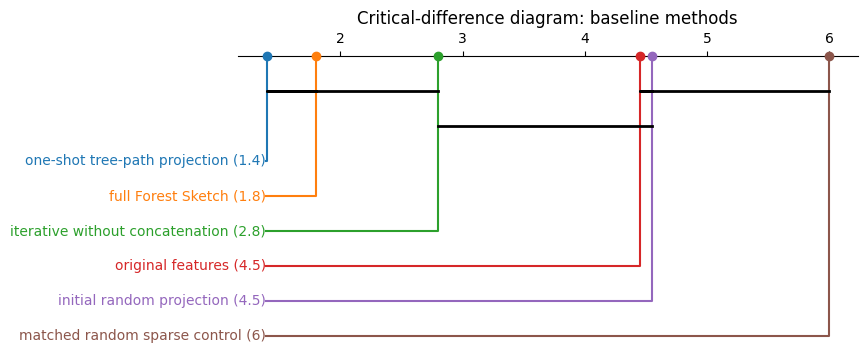

one-shot tree-path projection            accuracy=0.856 ± 0.018 errors=90.1 ± 10.9
full Forest Sketch                       accuracy=0.844 ± 0.025 errors=97.6 ± 15.6
iterative without concatenation          accuracy=0.829 ± 0.028 errors=106.6 ± 17.3
original features                        accuracy=0.706 ± 0.054 errors=183.5 ± 33.6
initial random projection                accuracy=0.706 ± 0.054 errors=183.6 ± 33.9
matched random sparse control            accuracy=0.508 ± 0.024 errors=307.3 ± 14.7


In [7]:
results = []
for seed in EXPERIMENT_SEEDS:
    X_train, X_test, y_train, y_test = make_dataset(seed)
    for name, model in build_models(seed).items():
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)
        accuracy = accuracy_score(y_test, prediction)
        errors = int(np.count_nonzero(prediction != y_test))
        results.append({'seed': seed, 'method': name, 'accuracy': accuracy, 'errors': errors})

results = pd.DataFrame(results)
summary = results.groupby('method').agg(
    mean_accuracy=('accuracy', 'mean'),
    std_accuracy=('accuracy', 'std'),
    mean_errors=('errors', 'mean'),
    std_errors=('errors', 'std'),
).sort_values('mean_accuracy', ascending=False)
display(summary.round({'mean_accuracy': 3, 'std_accuracy': 3, 'mean_errors': 1, 'std_errors': 1}))

fig, axis = plt.subplots(figsize=(12, 5))
axis.bar(
    summary.index,
    summary['mean_accuracy'],
    yerr=summary['std_accuracy'],
    capsize=5,
    color='steelblue',
)
axis.set_title('Baseline accuracy across random seeds')
axis.set_ylabel('Accuracy (mean ± standard deviation)')
axis.set_ylim(0, 1)
axis.tick_params(axis='x', rotation=25)
axis.grid(axis='y', alpha=0.25)
plt.show()
plot_critical_difference(
    results,
    block_column='seed',
    method_column='method',
    title='Critical-difference diagram: baseline methods',
)
plt.show()

for method, row in summary.iterrows():
    print(f'{method:40s} accuracy={row.mean_accuracy:.3f} ± {row.std_accuracy:.3f} errors={row.mean_errors:.1f} ± {row.std_errors:.1f}')


Interpret the result together with fit time, transform time, memory, and model size. The bars show the mean over five seeds and the error bars show one standard deviation; the printed error counts are integers for each run. A single accuracy win is not sufficient evidence: repeat this comparison across datasets, then use cross-validation to select n_components and n_iterations.